<a href="https://colab.research.google.com/github/Marium-pixel/AI_24K0906/blob/main/Assignment10%2611.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#task1:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")
df = df.sample(n=100000, random_state=42)

print("Class Distribution:\n", df['Class'].value_counts())

from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

Class Distribution:
 Class
0    99839
1      161
Name: count, dtype: int64

Logistic Regression
Accuracy : 0.968
Precision: 0.04491017964071856
Recall   : 0.9375
F1 Score : 0.08571428571428572

Random Forest
Accuracy : 0.9995
Precision: 0.851063829787234
Recall   : 0.8333333333333334
F1 Score : 0.8421052631578947



Linear Regression
MAE : 23473.76601288706
RMSE: 93251.40063203246

Decision Tree
MAE : 26450.86529680365
RMSE: 40950.88558849168


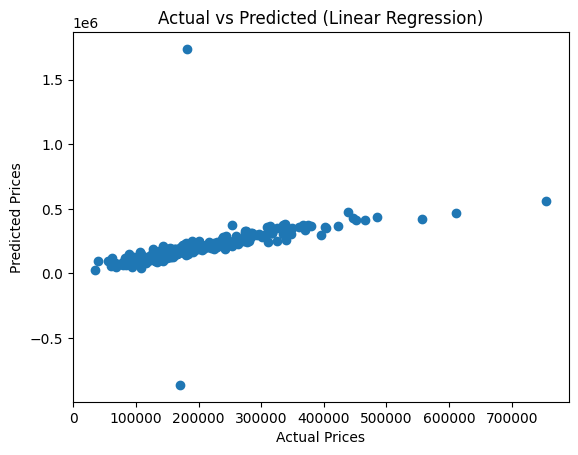

In [3]:
#task2:
# Task 2: House Price Prediction

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/train.csv")

# Drop ID column
df.drop("Id", axis=1, inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna("None", inplace=True)

df = pd.get_dummies(df)

from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")

# Predicted vs Actual Plot
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

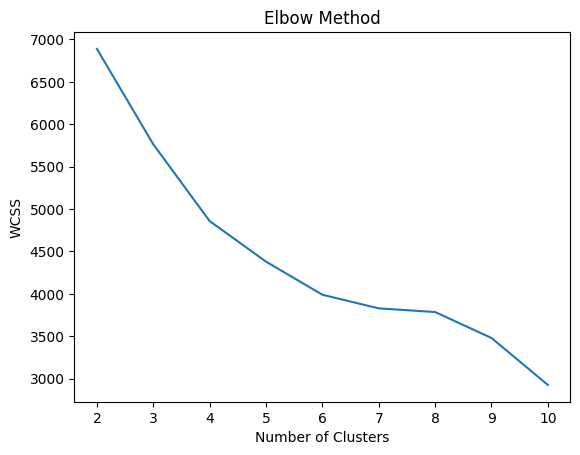

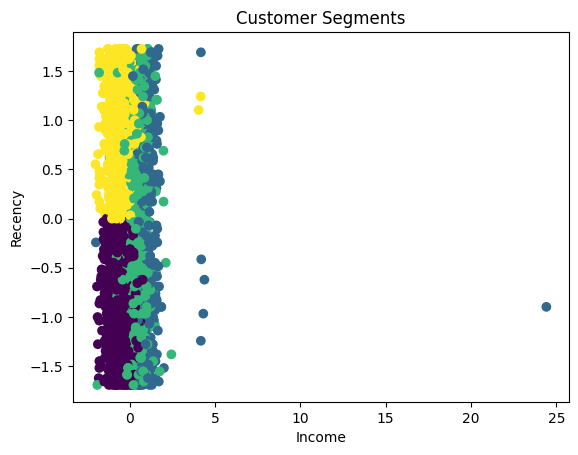

In [1]:
#task3:

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/marketing_campaign.csv", sep="\t")

df.dropna(inplace=True)

features = ["Income", "Recency", "MntWines", "MntMeatProducts", "NumWebPurchases"]
X = df[features]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Income")
plt.ylabel("Recency")
plt.title("Customer Segments")
plt.show()